# Load Libraries

In [5]:
import os
import warnings
import logging
import sys
import pickle
import numpy as np
import pandas as pd
import geopandas as gpd
import dotenv
import pyet

# Load environment variables from .env file
dotenv.load_dotenv()

# Set up logging
logging.basicConfig(level=logging.INFO)

# Suppress warnings
warnings.filterwarnings("ignore")

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', None)

# Load Data

In [6]:
# Load Data From Pickle
# with open('../../data/Khorasan_Data_1950_2025.pkl', 'rb') as f:
with open('../../data/Iran_Daily_Data_1950_2025.pkl', 'rb') as f:
    data = pickle.load(f)
    logging.info("Data loaded from pickle file.")

INFO:root:Data loaded from pickle file.


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4928062 entries, 0 to 4928061
Data columns (total 17 columns):
 #   Column             Dtype         
---  ------             -----         
 0   station_id         category      
 1   station_name       category      
 2   region_id          category      
 3   region_name        category      
 4   lat                float64       
 5   lon                float64       
 6   station_elevation  float64       
 7   date               datetime64[ns]
 8   tmax               float64       
 9   tmin               float64       
 10  tm                 float64       
 11  umax               float64       
 12  umin               float64       
 13  um                 float64       
 14  ffm                float64       
 15  sshn               float64       
 16  rrr24              float64       
dtypes: category(4), datetime64[ns](1), float64(12)
memory usage: 517.0 MB


# Fill Missing Dates

In [8]:
# Fill missing dates for each station with NaN
all_dates = pd.date_range(data['date'].min(), data['date'].max(), freq='D')

def reindex_station(station_df):
    # print(f"Reindexing station {station_df['station_id'].iloc[0]}")
    # print(station_df)
    return station_df.drop_duplicates().set_index('date').reindex(all_dates).assign(
        region_id=station_df['region_id'].iloc[0],
        region_name=station_df['region_name'].iloc[0],
        station_id=station_df['station_id'].iloc[0],
        station_name=station_df['station_name'].iloc[0],
        station_elevation=station_df['station_elevation'].iloc[0],
        lat=station_df['lat'].iloc[0],
        lon=station_df['lon'].iloc[0],
    ).reset_index().rename(columns={'index': 'date'})

data = (
    data.groupby(['region_id', 'region_name', 'station_id', 'station_name', 'station_elevation', 'lat', 'lon'], group_keys=False)
    .apply(reindex_station)
    .reset_index(drop=True)
)

data

Reindexing station 18554
       station_id       station_name region_id region_name   lat   lon  \
110432      18554  Zidashte Taleghan      ALKK      Alborz 36.13 50.68   
110433      18554  Zidashte Taleghan      ALKK      Alborz 36.13 50.68   
110434      18554  Zidashte Taleghan      ALKK      Alborz 36.13 50.68   
110435      18554  Zidashte Taleghan      ALKK      Alborz 36.13 50.68   
110436      18554  Zidashte Taleghan      ALKK      Alborz 36.13 50.68   
...           ...                ...       ...         ...   ...   ...   
111290      18554  Zidashte Taleghan      ALKK      Alborz 36.13 50.68   
111291      18554  Zidashte Taleghan      ALKK      Alborz 36.13 50.68   
111292      18554  Zidashte Taleghan      ALKK      Alborz 36.13 50.68   
111293      18554  Zidashte Taleghan      ALKK      Alborz 36.13 50.68   
111294      18554  Zidashte Taleghan      ALKK      Alborz 36.13 50.68   

        station_elevation                date  tmax  tmin    tm  umax  umin  \
110432 

,date,station_id,station_name,region_id,region_name,lat,lon,station_elevation,tmax,tmin,tm,umax,umin,um,ffm,sshn,rrr24
0,1951-01-01 12:00:00,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1951-01-02 12:00:00,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1951-01-03 12:00:00,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1951-01-04 12:00:00,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1951-01-05 12:00:00,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21152070,2025-09-17 12:00:00,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,31.40,16.90,24.10,41.00,18.00,26.17,3.17,10.70,0.00
21152071,2025-09-18 12:00:00,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,30.90,16.70,23.80,33.00,18.00,24.25,3.25,10.80,0.00
21152072,2025-09-19 12:00:00,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,35.70,17.50,26.60,28.00,8.00,17.70,3.13,10.00,0.00
21152073,2025-09-20 12:00:00,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,32.60,19.40,26.00,27.00,5.00,18.00,3.14,11.00,0.00


# Convert Daily Data to Monthly Data

In [11]:
data = data.set_index('date')

agg_dict = {
    'station_id': 'first',
    'station_name': 'first',
    'region_id': 'first',
    'region_name': 'first',
    'lat': 'first',
    'lon': 'first',
    'station_elevation': 'first',

    'tmax': 'mean',
    'tmin': 'mean',
    'tm': 'mean',
    'umax': 'mean',
    'umin': 'mean',
    'um': 'mean',
    'ffm': 'mean',
    'sshn': 'mean',

    'rrr24': 'sum'
}

data_monthly = (
    data
    .groupby(['region_id', 'station_id'], group_keys=False)
    .resample('M')
    .agg(agg_dict)
    .reset_index()
)


In [ ]:
data_monthly = data_monthly.set_index('date')
data_monthly.index = data_monthly.index.to_period('M').to_timestamp(how='start') + pd.Timedelta(days=14)
data_monthly = data_monthly.reset_index().rename(columns={'index': 'date'})
data_monthly

,date,station_id,station_name,region_id,region_name,lat,lon,station_elevation,tmax,tmin,tm,umax,umin,um,ffm,sshn,rrr24
0,1951-01-31,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
1,1951-02-28,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
2,1951-03-31,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
3,1951-04-30,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
4,1951-05-31,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694273,2025-05-31,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,32.10,18.04,25.07,36.13,14.87,23.45,3.39,10.69,4.21
694274,2025-06-30,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,33.87,20.21,27.04,33.67,15.43,22.38,3.95,11.86,0.20
694275,2025-07-31,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,37.27,24.75,31.03,30.45,15.19,21.33,4.77,10.66,0.20
694276,2025-08-31,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,36.37,23.30,29.83,26.03,13.68,18.72,4.63,11.78,0.00


# Calculate ETo

#### Data Quality Control

In [15]:
def data_quality_control(
    df, 
    required_vars = ['tm']
):
    # Remove duplicates
    df = df[~df.duplicated(keep='first')]
    # Drop rows with missing essential variables
    df = df.dropna(subset=required_vars)
    # Clip or filter out physically impossible values (example thresholds, adjust as needed)
    if 'tm' in required_vars:
        df = df[(df['tm'] > -50) & (df['tm'] < 60)]
    if 'tmax' in required_vars:
        df = df[(df['tmax'] > -50) & (df['tmax'] < 70)]
    if 'tmin' in required_vars:
        df = df[(df['tmin'] > -60) & (df['tmin'] < 50)]
    if 'ffm' in required_vars:
        df = df[(df['ffm'] >= 0) & (df['ffm'] < 50)]
    if 'um' in required_vars:
        df = df[(df['um'] >= 0) & (df['um'] <= 100)]
    if 'umax' in required_vars:
        df = df[(df['umax'] >= 0) & (df['umax'] <= 100)]
    if 'umin' in required_vars:
        df = df[(df['umin'] >= 0) & (df['umin'] <= 100)]
    if 'sshn' in required_vars:
        df = df[(df['sshn'] >= 0) & (df['sshn'] <= 24)]
    return df

#### Calculate ETo

In [16]:

def calculate_eto_pm_fao56(group):
    print(f"Calculating ETo pm_fao56 for station {group.name}")
    group = data_quality_control(
        df=group, 
        required_vars=['tm', 'tmax', 'tmin', 'um', 'umin', 'umax', 'ffm', 'sshn', 'lat', 'station_elevation']
    )
    group = group.set_index('date').sort_index()

    # If group is empty after cleaning, return NaNs
    if group.empty:
        return pd.Series(np.nan, index=group.index)

    lat = pyet.utils.deg_to_rad(lat=group['lat'].iloc[0])
    elevation = group['station_elevation'].iloc[0]
    rs = pyet.calc_rad_sol_in(n=group['sshn'], lat=lat, as1=0.25, bs1=0.5, nn=None)    
    wind = group['ffm']
    tmean = group['tm']
    tmax = group["tmax"]
    tmin = group["tmin"]
    rh = group["um"]
    rhmax = group["umin"]
    rhmin = group["umax"]
    
    eto = pyet.pm_fao56(
        tmean=tmean,
        wind=wind,
        rs=rs,
        elevation=elevation,
        lat=lat,
        tmax=tmax,
        tmin=tmin,
        rh=rh,
        rhmax=rhmax,
        rhmin=rhmin
    )

    return eto


def calculate_eto_hargreaves(group):
    print(f"Calculating ETo hargreaves for station {group.name}")
    group = data_quality_control(
        df=group, 
        required_vars=['tm', 'tmax', 'tmin', 'lat']
    )
    group = group.set_index('date').sort_index()

    # If group is empty after cleaning, return NaNs
    if group.empty:
        return pd.Series(np.nan, index=group.index)

    lat = pyet.utils.deg_to_rad(lat=group['lat'].iloc[0])
    tmean = group['tm']
    tmax = group["tmax"]
    tmin = group["tmin"]
    
    eto = pyet.hargreaves(
        tmean=tmean,
        tmax=tmax,
        tmin=tmin,
        lat=lat,
        k=0.0135,
        method=0,
        clip_zero=True
    )

    return eto

eto_df_pm_fao56 = data_monthly.groupby(
    ['region_id', 'station_id'],
    group_keys=True
).apply(calculate_eto_pm_fao56)

eto_df_hargreaves = data_monthly.groupby(
    ['region_id', 'station_id'],
    group_keys=True
).apply(calculate_eto_hargreaves)

Calculating ETo pm_fao56 for station ('ALKK', '18554')
Calculating ETo pm_fao56 for station ('ALKK', '18590')
Calculating ETo pm_fao56 for station ('ALKK', '18592')
Calculating ETo pm_fao56 for station ('ALKK', '18593')
Calculating ETo pm_fao56 for station ('ALKK', '18607')
Calculating ETo pm_fao56 for station ('ALKK', '18622')
Calculating ETo pm_fao56 for station ('ALKK', '18632')
Calculating ETo pm_fao56 for station ('ALKK', '18703')
Calculating ETo pm_fao56 for station ('ALKK', '18712')
Calculating ETo pm_fao56 for station ('ALKK', '40752')
Calculating ETo pm_fao56 for station ('ALKK', '75201')
Calculating ETo pm_fao56 for station ('ALKK', '88125')
Calculating ETo pm_fao56 for station ('ALKK', '90220')
Calculating ETo pm_fao56 for station ('ALKK', '99321')
Calculating ETo pm_fao56 for station ('ALKK', '99373')
Calculating ETo pm_fao56 for station ('ALKK', '99396')
Calculating ETo pm_fao56 for station ('MAAA', '18915')
Calculating ETo pm_fao56 for station ('MAAA', '18975')
Calculatin

#### Join ETo with Original Data

In [17]:
if isinstance(eto_df_pm_fao56.index, pd.MultiIndex):
    eto_df_pm_fao56 = eto_df_pm_fao56.reset_index().rename(columns={0:'FAO56'})
    data_monthly = pd.merge(data_monthly, eto_df_pm_fao56, on=['region_id', 'station_id', 'date'], how='left')
else:
    data_monthly = data_monthly.join(eto_df_pm_fao56)

if isinstance(eto_df_hargreaves.index, pd.MultiIndex):
    eto_df_hargreaves = eto_df_hargreaves.reset_index().rename(columns={0:'Hargreaves'})
    data_monthly = pd.merge(data_monthly, eto_df_hargreaves, on=['region_id', 'station_id', 'date'], how='left')
else:
    data_monthly = data_monthly.join(eto_df_hargreaves)

data_monthly

,date,station_id,station_name,region_id,region_name,lat,lon,station_elevation,tmax,tmin,tm,umax,umin,um,ffm,sshn,rrr24,FAO56,Hargreaves
0,1951-01-15,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN
1,1951-02-15,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN
2,1951-03-15,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN
3,1951-04-15,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN
4,1951-05-15,18554,Zidashte Taleghan,ALKK,Alborz,36.13,50.68,2255.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694273,2025-05-15,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,32.10,18.04,25.07,36.13,14.87,23.45,3.39,10.69,4.21,7.91,6.06
694274,2025-06-15,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,33.87,20.21,27.04,33.67,15.43,22.38,3.95,11.86,0.20,9.16,6.50
694275,2025-07-15,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,37.27,24.75,31.03,30.45,15.19,21.33,4.77,10.66,0.20,10.61,6.67
694276,2025-08-15,99440,Kahak,QOQM,Qom,34.40,50.87,1403.10,36.37,23.30,29.83,26.03,13.68,18.72,4.63,11.78,0.00,10.31,6.12


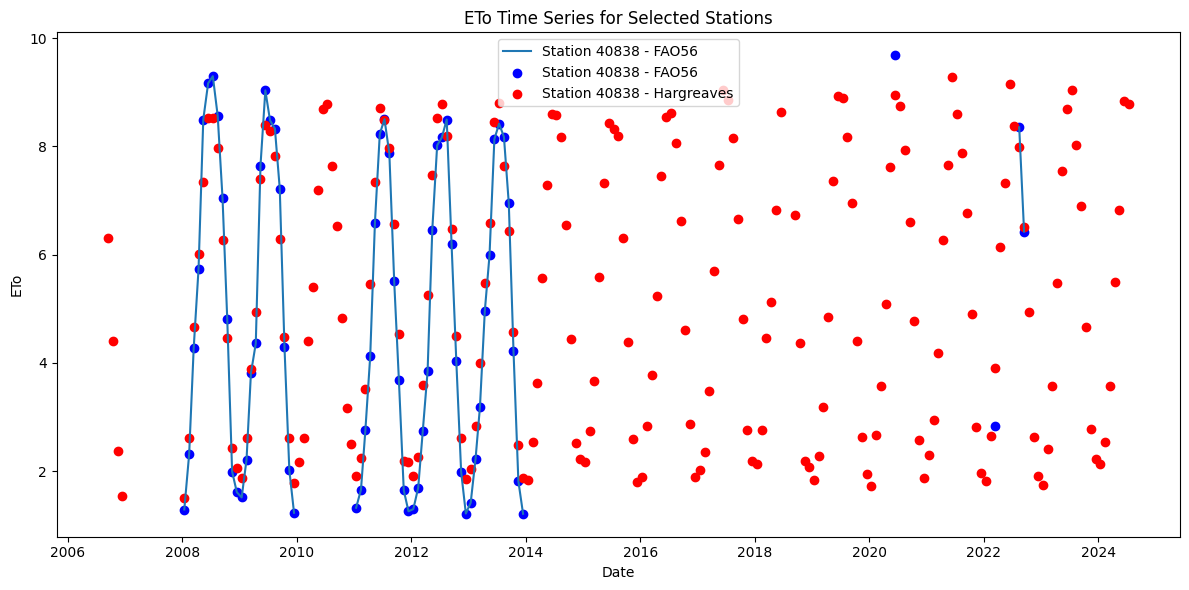

In [31]:
import matplotlib.pyplot as plt

# Select a few station_ids to plot (change as needed) + FAO56 and Hargreaves (point and line)
stations_to_plot = data_monthly['station_id'].drop_duplicates().sample(1)

plt.figure(figsize=(12, 6))
for sid in stations_to_plot:
    station_data = data_monthly[data_monthly['station_id'] == sid].sort_values('date')
    plt.plot(station_data['date'], station_data['FAO56'], label=f'Station {sid} - FAO56')
    plt.scatter(station_data['date'], station_data['FAO56'], color='blue', label=f'Station {sid} - FAO56')
    plt.scatter(station_data['date'], station_data['Hargreaves'], color='red', label=f'Station {sid} - Hargreaves')

plt.xlabel('Date')
plt.ylabel('ETo')
plt.title('ETo Time Series for Selected Stations')
plt.legend()
plt.tight_layout()
plt.show()

# Change Column Names

In [13]:
result.columns

Index(['date', 'station_id', 'station_name', 'region_id', 'region_name', 'lat',
       'lon', 'station_elevation', 'tmax', 'tmin', 'tm', 'umax', 'umin', 'um',
       'ffm', 'sshn', 'rrr24', 'FAO56', 'Hargreaves'],
      dtype='object')

In [ ]:
# result.rename(
#     columns={
#         'FAO-56': 'FAO56',
#         'Priestley-Taylor': 'PriestleyTaylor',
#         'Kimberly-Penman': 'KimberlyPenman',
#         'Thom-Oliver': 'ThomOliver',
#         'Blaney-Criddle': 'BlaneyCriddle',
#         'Jensen-Haise': 'JensenHaise',
#         'Mcguinness-Bordne': 'McguinnessBordne',
#         'FAO-24': 'FAO24',
#     }, 
#     inplace=True
# )

# Export Data

In [14]:
# To pickle in data folder
# with open('../../data/Khorasan_ETo_1950_2025.pkl', 'wb') as f:
with open('../../data/Iran_ETo_1950_2025.pkl', 'wb') as f:
    pickle.dump(result, f)